In [72]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from scipy.linalg import circulant
from torch.autograd import Variable

from sklearn.model_selection import train_test_split

from util.DataGen import nai_pulse
from util.Processing import td_convolve, td_nnlsr_deconvolve
from util.Plotting import plot_photons

In [73]:
device = torch.device("cuda")

(1000,) (1000,)


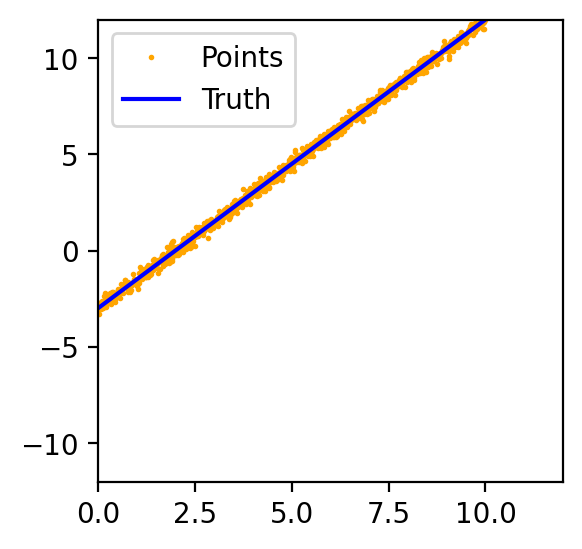

In [74]:
m = 1.5
b = -3
noise_std = .2
n = 1000

x = np.linspace(0, 10, n)
y_true = m * x + b
y = y_true + np.random.normal(loc=0, scale=noise_std, size=n)

print(x.shape, y.shape)

plt.figure(figsize=(3,3), dpi=200)
plt.plot(x, y, 'orange', marker='.', linestyle='', markersize=2, label='Points')
plt.plot(x, y_true, 'b-', label='Truth')

mx = max(np.max(x), np.max(y_true))
plt.xlim(0,mx)
plt.ylim(-mx,mx)
plt.legend()

In [75]:
# Y = Variable(torch.tensor(y_meas), requires_grad=True).to(device)
# X = Variable(torch.ones_like(Y), requires_grad=True).to(device)
# mp = Variable(torch.tensor(np.array([0.])), requires_grad=True).to(device)
# bp = Variable(torch.tensor(np.array([0.])), requires_grad=True).to(device)
# 
# print(Y.shape, X.shape, mp.shape, bp.shape)
# 
# fig, axes = plt.subplots(3,1, figsize=(8,6), dpi=200)
# 
# losses = []
# ms = []
# bs = []
# 
# # Hyperparameters
# lr = .0001
# n = 1000
# 
# for i in range(n):
#     with torch.enable_grad():
#         # print(mp,bp)
#                   
#         mp.retain_grad()
#         bp.retain_grad()
#         
#         ms.append(mp.detach().cpu().item())
#         bs.append(bp.detach().cpu().item())
#         
#         Yp = mp * X + bp
#         
#         residual = (Y - Yp) ** 2      
#         sum_R = torch.sum(residual)
#         sum_R_val = sum_R.detach().item()
#         losses.append(sum_R_val)
# 
#         # Backpropogate
#         total_loss = sum_R
#         total_loss.backward()
#         
#         mp = mp - lr * mp.grad
#         bp = bp - lr * bp.grad
#         
#         mp.grad = torch.tensor([0.]).double().to(device)
#         bp.grad = torch.tensor([0.]).double().to(device)
# 
# mhat = mp.detach().item()
# bhat = bp.detach().item()
# 
# print(mhat, bhat)
# y_model = mhat * x + b
# 
# axes[0].plot(losses, label='Loss')
# axes[0].legend()
# axes[0].set_yscale('log')
# 
# axes[1].plot(ms, label='m over time')
# axes[1].plot(bs, label='b over time')
# axes[1].legend()
# 
# axes[2].plot(x, y_meas, 'orange', marker='.', linestyle='', markersize=2, label='Points')
# axes[2].plot(x, y_true, 'b-', label='Truth')
# axes[2].plot(x, y_model, 'g-', label='Model')
# 
# mx = max(np.max(x), np.max(y_true))
# axes[2].set_xlim(0,mx)
# axes[2].set_ylim(-5,mx)
# axes[2].legend()


In [76]:
# class linearRegression(torch.nn.Module):
#     def __init__(self, inputSize, outputSize):
#         super(linearRegression, self).__init__()
#         self.linear = torch.nn.Linear(inputSize, outputSize)
# 
#     def forward(self, x):
#         print(x.shape)
#         out = self.linear(x)
#         return out
#     
# inputDim = 1        # takes variable 'x' 
# outputDim = 1       # takes variable 'y'
# learningRate = 0.01 
# epochs = 100
# 
# model = linearRegression(inputDim, outputDim)
# ##### For GPU #######
# if torch.cuda.is_available():
#     model.cuda()
#     
# criterion = torch.nn.MSELoss() 
# optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)
# 
# x_train, x_test, y_train, y_test = train_test_split(x,y)
#     
# for epoch in range(epochs):
#     # Converting inputs and labels to Variable
#     if torch.cuda.is_available():
#         inputs = Variable(torch.from_numpy(x_train).float().cuda())
#         labels = Variable(torch.from_numpy(y_train).float().cuda())
#     else:
#         inputs = Variable(torch.from_numpy(x_train))
#         labels = Variable(torch.from_numpy(y_train))
#         
#     print(inputs.shape, labels.shape)
# 
#     # Clear gradient buffers because we don't want any gradient from previous epoch to carry forward, dont want to cummulate gradients
#     optimizer.zero_grad()
# 
#     # get output from the model, given the inputs
#     outputs = model(inputs)
# 
#     # get loss for the predicted output
#     loss = criterion(outputs, labels)
#     print(loss)
#     # get gradients w.r.t to parameters
#     loss.backward()
# 
#     # update parameters
#     optimizer.step()
# 
#     print('epoch {}, loss {}'.format(epoch, loss.item()))
#     
# with torch.no_grad(): # we don't need gradients in the testing phase
#     if torch.cuda.is_available():
#         predicted = model(Variable(torch.from_numpy(x_train).cuda())).cpu().data.numpy()
#     else:
#         predicted = model(Variable(torch.from_numpy(x_train))).data.numpy()
#     print(predicted)
# 
# plt.clf()
# plt.plot(x_train, y_train, 'go', label='True data', alpha=0.5)
# plt.plot(x_train, predicted, '--', label='Predictions', alpha=0.5)
# plt.legend(loc='best')
# plt.show()

cpu cpu
1.4820095300674438 -2.8787410259246826


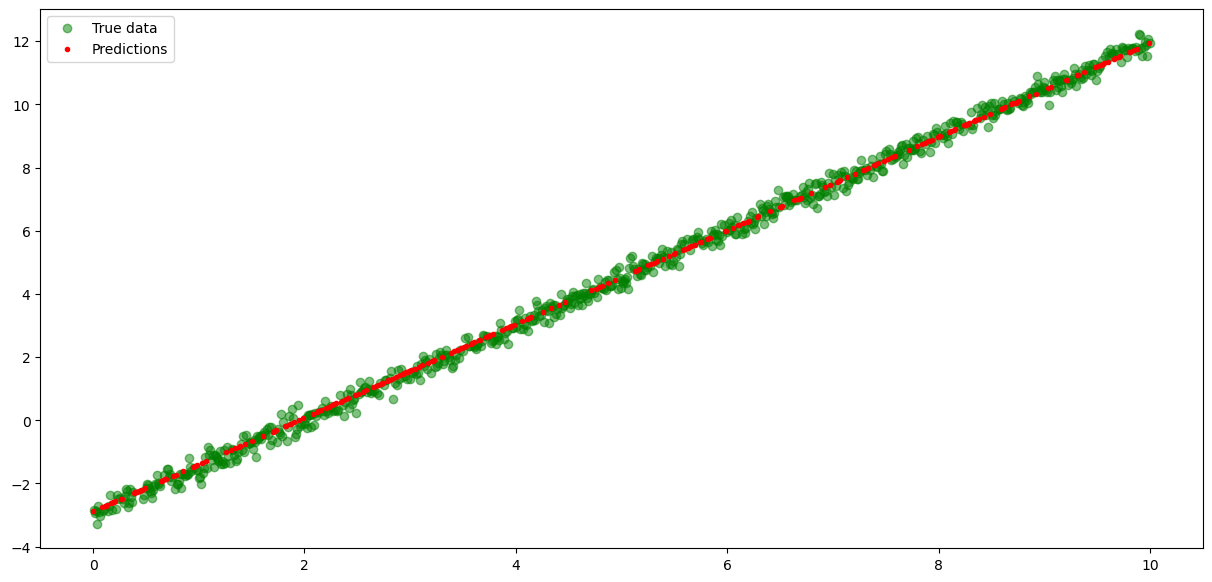

In [77]:
import torch

x_train, x_test, y_train, y_test = train_test_split(x,y)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

x_train = torch.from_numpy(x_train).float().reshape((-1,1))
x_test = torch.from_numpy(x_test).float().reshape((-1,1))
y_train = torch.from_numpy(y_train).float().reshape((-1,1))
y_test = torch.from_numpy(y_test).float().reshape((-1,1))

class LinearRegressionModel(torch.nn.Module):
    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        self.linear = torch.nn.Linear(1, 1)  # One in and one out

    def forward(self, x):
        y_pred = self.linear(x)
        return y_pred

model = LinearRegressionModel()
# if torch.cuda.is_available():
#     model.to(device)
    
print(model.linear.weight.device, model.linear.bias.device)

criterion = torch.nn.MSELoss(size_average = False)
optimizer = torch.optim.SGD(model.parameters(), lr=1E-6)

# Note: learning rate dependent on batch size!!!!!
for epoch in range(10000):
    # print(model.linear.weight, model.linear.bias,'\n')
    pred_y = model(x_train)
    
    loss = criterion(pred_y, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
print(model.linear.weight.item(), model.linear.bias.item())
    
predicted = model(x_test)
plt.clf()
plt.plot(x_train.cpu().detach().numpy(), y_train.cpu().detach().numpy(), 'go', label='True data', alpha=0.5)
plt.plot(x_test.cpu().detach().numpy(), predicted.cpu().detach().numpy(), 'r.', label='Predictions', alpha=1)
plt.legend(loc='best')
plt.show()
